# Monte Carlo Portfolio Simulator 
**Author:** Zenith Lee

## Project Overview
This project implements a vectorized Monte Carlo Simulation engine using **Geometric Brownian Motion (GBM)** to project future price paths for a customizable multi-asset portfolio. By calculating historical covariance and applying a **Cholesky Decomposition**, the simulation strictly preserves the real-wrold correlation structure between assets (e.g., how cryptocurrencies move relative to large-cap equities).

## Motivation & Application
The primary inspiration for building this engine is to rigorously assess the risk profile of a personal investment porfolio. Instead of relying on static expected returns, this tool enables dynamic, forward-looking risk managment. Specifically, it is designed to:
* **Quantify Downside Risk:** Calcualte the 95% Confidence Value-at-Risk (VaR) to understand potential portfolio drawdowns.
* **Optimise Allocation:** Evaluate whether current positon weightings need to be rebalanced based on simulated risk.
* **Strategic Hedging:** Simulate the impact of introducing inversely correlated assests to hedge the portfolio against systematic market shocks.

## Future Scope
While this iniital iteration focuses on equities and standard crypto assets, the underlying stochastic calculus engine lays the groundwork for derivative pricing. Futur enhancements will involve adapting the paths to price European and path-dependent **Options**, allowing for the simulation of complex portfolio insurance strategies.

---
### Environment Setup & Initial Parameters
In the cell below, we define the target portfolio universe. The system is designed to be full dynamic: the `tickers` and `weights` arrays can be modified at any time to instantly re-run the simulation for a different asset mix. 

In [29]:
import numpy as np
import pandas as pd 
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

tickers = ['QQQ', 'BTC-USD', 'TLT', 'GLD'] # Can be modified to desired portfolio
weights = np.array([0.4, 0.2, 0.2, 0.2])  # Can be modified to desired portfolio

simulations = 10000
time_horizon = 252 # 1 year
seed = 42 
np.random.seed(seed)


if not np.isclose (weights.sum(), 1.0): # check if weights == 1.0
    print(f"ERROR: Sum of weights not equal to 1.0.")
   

### Step 1: Historical Parameter Estimation
To simulate future price paths using Geometric Brownian Motion ($dS_t = \mu S_t dt + \sigma S_t dW_t$), where $S_t$ represents the continuous **stochastic process** of the asset's price and $dW_t$ represents the random shocks driven by a **Wiener Process** (Standard Brownian Motion), we must estimate three historical parameters for each asset in our portfolio:

1. **Drift ($\mu$):** The annualized expected return.
2. **Volatility ($\sigma$):** The annualized standard deviation of returns (risk).
3. **Correlation Matrix ($\rho$):** The structural relationship between the assets.

### Methodology Note: Why Log Returns?
In this engine, we calculate **Logarithmic Returns** ($R_t = \ln(P_t / P_{t-1})$) rather than simple arithmetic returns. This is a critical mathematical requirement for continuous-time modeling for two main reasons:

**1. Time Additivity (Converting Multiplication to Addition):**
Asset prices compound multiplicatively over time. To calculate a multi-period return using simple returns, the sequential growth rates must be multiplied. However, logarithms possess the mathematical property of converting multiplication into addition. By taking the natural log of the returns, the total continuous return over a period becomes the simple sum of the daily log returns. Because our Monte Carlo engine works by iteratively adding random shocks step-by-step to build a price path, we must use a return metric that is linearly additive.

**2. The Normality Assumption and Price Boundaries:**
Standard Monte Carlo simulations assume that the random variables (the daily shocks) follow a normal  distribution, which theoretically extends to negative infinity. Simple returns are bounded on the downside at -100%, meaning they cannot be truly normally distributed. Log returns resolve this boundary issue. As an asset's price approaches zero, its log return approaches negative infinity. Because log returns are unbounded in both directions, they can safely be modeled with a normal distribution. This guarantees that the resulting simulated asset prices follow a "log-normal" distribution, strictly ensuring the simulated asset price never drops below zero.

In [30]:
end_date = datetime.now()
start_date = end_date - timedelta(days=2*365)

print(f"Fetching data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}...")

df = yf.download(tickers, start=start_date, end=end_date)['Close']
df.dropna(inplace=True)

log_returns = np.log(df/df.shift(1)).dropna()

mu = log_returns.mean() * 252
cov_matrix = log_returns.cov() * 252 # variance scale linearly with time, vol scale with square root time
corr_matrix = log_returns.corr()

print("\n--- Annualized Volatility (Risk) ---")
volatility = np.sqrt(np.diag(cov_matrix)) # volatility is the square root of the variance (the diagonal of the covariance matrix)
for ticker, vol in zip(tickers, volatility):
    print(f"{ticker}: {vol*100:.2f}%")

print("\n--- Correlation Matrix ---")
print(corr_matrix.round(3))

[*********************100%***********************]  1 of 1 completed

Fetching data from 2024-03-28 to 2026-03-28...

--- Annualized Volatility (Risk) ---
QQQ: 21.03%

--- Correlation Matrix ---
Ticker  QQQ
Ticker     
QQQ     1.0


### Step 2: Correlating Shocks via Cholesky Decomposition

**The Independence Problem:**
A standard random number generator produces **independent** variables. Statistically, this means the covariance of our simulated shocks ($Z_{independent}$) is the **Identity Matrix**. The simulated assets have no relationship to each other. If we use these raw numbers, our model will assume the assets perfectly diversify each other, drastically underestimating our portfolio's systematic risk.

**The Solution (Linear Transformation):**
To fix this, we must carry forward the historical correlation relationship of the assets ($\Sigma$) calculated in Step 1. We do this by applying a **linear transformation** to our independent variables using the **Cholesky Decomposition**.

By decomposing our historical correlation matrix, we find a lower-triangular matrix $L$ such that:
$$\Sigma = L \cdot L^T$$

$L$ acts as the geometric instructions to stretch and skew our data. By taking the dot product of $L$ and our independent standard normal draws, we transform that Identity Matrix into our target correlation matrix. This mathematically guarantees that our simulated variables will move together exactly as they did in the historical data:
$$Z_{correlated} = L \cdot Z_{independent}$$

In [31]:
L = np.linalg.cholesky(corr_matrix) # use in build function to get lower_triangular matrix L

days = int(time_horizon)
num_assets = len(tickers)

Z_indep = np.random.standard_normal((days, num_assets, simulations)) # 3D array

Z_corr = np.zeros_like(Z_indep) # new array of the same shape

for t in range(days): # transforms shocks on t day to correlated shocks accross all simulations via dot product
    Z_corr[t] = L @ Z_indep[t]

print(f"Successfully generated {simulations} correlated simulation paths.")
print(f"Independent Matrix Shape: {Z_indep.shape}")
print(f"Correlated Matrix Shape:  {Z_corr.shape}")

Successfully generated 10000 correlated simulation paths.
Independent Matrix Shape: (252, 1, 10000)
Correlated Matrix Shape:  (252, 1, 10000)


### Step 3: Simulating the Price Paths (Geometric Brownian Motion)
With our correlated random shocks generated, we can now simulate the future price paths. We use the discrete-time formula for Geometric Brownian Motion (GBM):

$$S_{t+\Delta t} = S_t \exp\left( \left( \mu - \frac{1}{2}\sigma^2 \right) \Delta t + \sigma \sqrt{\Delta t} Z_{correlated} \right)$$

**The "Volatility Drag" Correction:**
The $- \frac{1}{2}\sigma^2$ inside the equation is a correction term derived from Ito's Lemma. Because asset prices compound multiplicatively over time, high volatility naturally eats away at your overall geometric returns. This term accounts for that **volatility drag**, ensuring our simulated future prices are mathematically accurate.

**Vectorization & Compounding:**
To optimize performance, we avoid using slow `for` loops to calculate prices day-by-day. Instead, we calculate the daily growth factors (exponential term) for all 100,000 universes at once. We then use NumPy's cumulative product (`np.cumprod`) to instantly compound those daily returns into continuous price paths. 

Finally, all individual asset paths are normalized to start at $1.0$, allowing us to easily calculate the total portfolio value by multiplying the paths by our initial portfolio weights.

In [32]:
prices = np.ones((days + 1, num_assets, simulations)) # +1 because row 0 will hold the starting price of 1.0

dt = 1 / 252  # time step is one trading day

for i in range(num_assets):
    asset_mu = mu.iloc[i]  
    asset_vol = np.sqrt(cov_matrix.iloc[i, i]) 

    growth_factors = np.exp((asset_mu - 0.5 * asset_vol**2) * dt + 
                            asset_vol * np.sqrt(dt) * Z_corr[:, i, :]) # scalar multiplication on all simulations and days of ith asset
    
    # Compound the daily growth into a continuous price path
    prices[1:, i, :] = np.cumprod(growth_factors, axis=0) # axis=0 to mulitply across rows representing days, *columns represent simulations

portfolio_paths = np.tensordot(prices, weights, axes=([1], [0])) # dot product of assets and weights, collaspe assets dimension to get total portfolio value

print("Simulation complete!")
print(f"Asset Prices Shape: {prices.shape}")
print(f"Portfolio Paths Shape: {portfolio_paths.shape} (Days, Simulations)")

Simulation complete!
Asset Prices Shape: (253, 1, 10000)
Portfolio Paths Shape: (253, 10000) (Days, Simulations)


### Step 4: Risk Analysis and Visualization 
With our simulated portfolio paths generated, we extract key risk metrics by analyzing the distribution of the final day's returns.

**1. Value-at-Risk (VaR):**
We calculate the **95% VaR**, which isolates the 5th percentile of our simulated outcomes. This tells us the maximum expected loss with 95% confidence over a 1-year horizon.

**2. Conditional VaR (Expected Shortfall):**
We also calculate Conditional VaR (CVaR), which takes the average of all losses that fall beyond the 95% VaR threshold. This answers the critical question: *"If things go wrong, exactly how bad will they get?"*

**Industry Benchmarks for 1-Year 95% VaR:**
* **< 5%:** Conservative (Heavy Bonds/Cash)
* **5% - 15%:** Moderate (60/40 Equity/Bond Mix)
* **15% - 25%:** Aggressive (100% Equities / S&P 500)
* **> 25%:** Highly Aggressive (Crypto, Tech, Options)
  
**3. Path-Dependent Risk (Maximum Drawdown):**
We calculate the **95% Expected Maximum Drawdown (MDD)** by finding the absolute deepest peak-to-trough drop for every single simulated universe, and extracting the 5th percentile worst-case scenario. This measures the "sleep at night" risk during the holding period.

**4. Risk-Adjusted Returns (Sharpe & Sortino):**
Assuming a 4.0% risk-free rate, we evaluate if the portfolio's expected returns justify its volatility. The **Sharpe Ratio** penalizes all volatility, while the **Sortino Ratio** specifically penalizes downside deviation.

**Visualization (The Representative Path):**
Finally, we visualize our simulation using a Monte Carlo fan chart. The expected mean path is dynamically colored green if the portfolio has a positive mathematical edge ($\geq 1.0$), and red if it is expected to lose money.

Rather than plotting a mathematically smoothed average (which eliminates realistic market noise), we isolate the single simulated universe that ended closest to our expected mean value. This "Representative Path" provides a highly realistic visualization of the typical daily volatility the portfolio will experience.

--- Portfolio Risk Metrics (1-Year Horizon) ---
Expected Final Value:           1.13x
95% Value-at-Risk (VaR):        -21.63%
95% Expected Shortfall (CVaR):  -28.05%
95% Expected Max Drawdown:      -32.03%
Sharpe Ratio:                   0.43
Sortino Ratio:                  0.76

--- Automated Risk Assessment ---
Profile: Aggressive
Notes:   High risk. Standard for growth-focused stock portfolios.



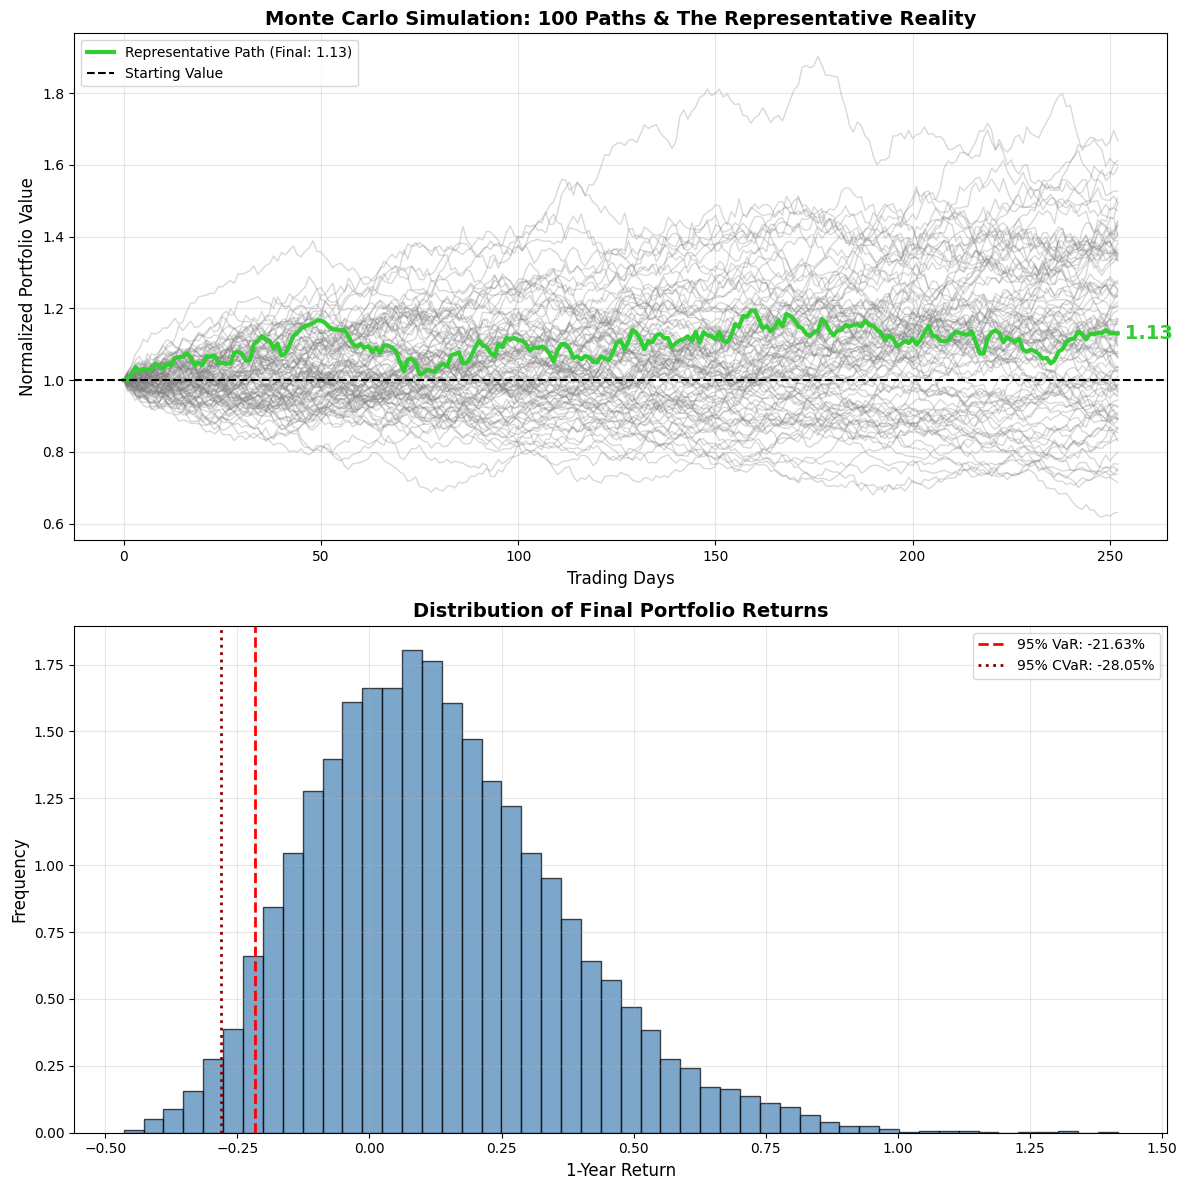

In [37]:
import matplotlib.pyplot as plt

# VaR & CVaR
final_values = portfolio_paths[-1, :]
portfolio_returns = final_values - 1.0
expected_final_value = final_values.mean()

confidence_level = 0.05
VaR_95 = np.percentile(portfolio_returns, confidence_level * 100)
CVaR_95 = portfolio_returns[portfolio_returns <= VaR_95].mean()

# Maximum Drawdown
running_max = np.maximum.accumulate(portfolio_paths, axis=0)
drawdowns = (portfolio_paths - running_max) / running_max

# Find the absolute deepest drawdown for each universe, then get the 95% worst-case
max_drawdowns = drawdowns.min(axis=0)
expected_mdd_95 = np.percentile(max_drawdowns, 5)

# Sharpe & Sortino
risk_free_rate = 0.04 

daily_returns = portfolio_paths[1:] / portfolio_paths[:-1] - 1

annualized_return = expected_final_value - 1.0
annualized_volatility = daily_returns.std() * np.sqrt(252)

# downside deviation for Sortino
negative_returns = np.where(daily_returns < 0, daily_returns, 0)
downside_deviation = negative_returns.std() * np.sqrt(252)

sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility
sortino_ratio = (annualized_return - risk_free_rate) / downside_deviation

# Representative path
# Find the specific simulation index that ended closest to our overall expected mean
differences = np.abs(final_values - expected_final_value)
representative_path_index = np.argmin(differences)
representative_path = portfolio_paths[:, representative_path_index]

# Benchmarks
var_pct = abs(VaR_95) * 100

if var_pct <= 5:
    risk_profile = "Conservative"
    assessment = "Excellent capital preservation. Typical of fixed income."
elif var_pct <= 15:
    risk_profile = "Moderate"
    assessment = "A balanced risk profile suitable for standard retirement funds."
elif var_pct <= 25:
    risk_profile = "Aggressive"
    assessment = "High risk. Standard for growth-focused stock portfolios."
else:
    risk_profile = "Highly Aggressive"
    assessment = "Extreme tail risk. Ensure position sizing accounts for severe drawdowns."


print(f"--- Portfolio Risk Metrics (1-Year Horizon) ---")
print(f"Expected Final Value:           {expected_final_value:.2f}x")
print(f"95% Value-at-Risk (VaR):        {VaR_95*100:.2f}%")
print(f"95% Expected Shortfall (CVaR):  {CVaR_95*100:.2f}%")
print(f"95% Expected Max Drawdown:      {expected_mdd_95*100:.2f}%")
print(f"Sharpe Ratio:                   {sharpe_ratio:.2f}")
print(f"Sortino Ratio:                  {sortino_ratio:.2f}\n")

print(f"--- Automated Risk Assessment ---")
print(f"Profile: {risk_profile}")
print(f"Notes:   {assessment}\n")


# Green if >= 1.0 , Red if < 1.0
mean_color = 'limegreen' if expected_final_value >= 1.0 else 'red'
final_day_index = len(representative_path) - 1

# Stacked charts (2 rows, 1 column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Plot 1: Fan Chart with Representative Path
ax1.plot(portfolio_paths[:, :100], alpha=0.3, linewidth=1, color='gray') 
ax1.plot(representative_path, color=mean_color, linewidth=3, 
         label=f'Representative Path (Final: {expected_final_value:.2f})') 

ax1.text(final_day_index, expected_final_value, f' {expected_final_value:.2f}', 
         color=mean_color, fontsize=14, fontweight='bold', va='center')

ax1.axhline(y=1.0, color='black', linestyle='--', label='Starting Value')
ax1.set_title('Monte Carlo Simulation: 100 Paths & The Representative Reality', fontsize=14, fontweight='bold')
ax1.set_xlabel('Trading Days', fontsize=12)
ax1.set_ylabel('Normalized Portfolio Value', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Histogram of Final Returns
ax2.hist(portfolio_returns, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(x=VaR_95, color='red', linestyle='dashed', linewidth=2, label=f'95% VaR: {VaR_95*100:.2f}%')
ax2.axvline(x=CVaR_95, color='darkred', linestyle='dotted', linewidth=2, label=f'95% CVaR: {CVaR_95*100:.2f}%')
ax2.set_title('Distribution of Final Portfolio Returns', fontsize=14, fontweight='bold')
ax2.set_xlabel('1-Year Return', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()